# Gas benchmark data for EIP-7904 operations - EDA

#### Maria Silva, January 2026

In [1]:
import os
import sys
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

## Load data

This data was generated from running the `estimate_opcode_run_times` script in this repo. The raw data comes from the repricing benchmarks between done between 2026-01-10 and 2026-01-22.

In [2]:
# Main directories
current_path = os.getcwd()
repo_dir = os.path.abspath(os.path.join(current_path, ".."))
report_dir = os.path.join(
    repo_dir, "reports", "eip-7904", "runtime_estimation", "2026-01-10_2026-01-23"
)
src_dir = os.path.join(repo_dir, "src")

In [3]:
sys.path.append(src_dir)
import operation_types

In [4]:
gas_bench_df = pd.read_csv(os.path.join(report_dir, "gas_bench_data.csv"))
gas_bench_df = gas_bench_df[
    gas_bench_df["test_opcode"].isin(
        operation_types.SIMPLE_EIP_7904 + operation_types.VARIABLE_EIP_7904
    )
]
gas_bench_df

,client_name,run_duration_ms,opcount,test_file,test_name,test_opcode,test_params
34,geth,687.00525,800,test_alt_bn128,test_alt_bn128,ECADD,bn128_add_infinities
67,geth,1142.79360,21000,test_arithmetic,test_arithmetic,MOD,NaN
71,geth,2135.41670,2000,test_blake2f,test_blake2f_benchmark,BLAKE2F,num_rounds_24
80,geth,991.37915,1000,test_keccak,test_keccak_diff_mem_msg_sizes,KECCAK256,msg_size_256-mem_size_0
95,geth,584.37146,1000,test_keccak,test_keccak_diff_mem_msg_sizes,KECCAK256,msg_size_32-mem_size_256
...,...,...,...,...,...,...,...
481634,geth,2456.34620,4800,test_keccak,test_keccak_diff_mem_msg_sizes,KECCAK256,msg_size_0-mem_size_0
481641,geth,788.22327,200,test_keccak,test_keccak_diff_mem_msg_sizes,KECCAK256,msg_size_1024-mem_size_1024
481646,geth,341.76453,600,test_keccak,test_keccak_diff_mem_msg_sizes,KECCAK256,msg_size_0-mem_size_32
481657,geth,3097.62450,2,test_point_evaluation,test_point_evaluation,POINT_EVALUATION,point_evaluation


In [5]:
results_df = (
    pd.read_csv(os.path.join(report_dir, "results.csv"))
    .sort_values("opcode")
)
results_df

,opcode,client,intercept,intercept_pvalue,rsquared,rsquared_adj,slope,slope_pvalue,slope_conf_int_low,slope_conf_int_high,...,mem_size_conf_int_low,mem_size_conf_int_high,num_rounds,num_rounds_pvalue,num_rounds_conf_int_low,num_rounds_conf_int_high,num_pairs,num_pairs_pvalue,num_pairs_conf_int_low,num_pairs_conf_int_high
43,BLAKE2F,nethermind,-120.084053,1.344055e-60,0.970016,0.969956,0.846912,0.000000e+00,0.837519,0.856306,...,NaN,NaN,10.767822,2.909051e-147,10.082898,11.452745,NaN,NaN,NaN,NaN
42,BLAKE2F,reth,-184.337095,1.117778e-30,0.920624,0.920339,0.817890,3.450935e-298,0.796940,0.838840,...,NaN,NaN,19.603935,2.574889e-88,18.004448,21.203422,NaN,NaN,NaN,NaN
41,BLAKE2F,besu,-135.390081,6.504018e-11,0.978126,0.978082,3.027807,0.000000e+00,2.999578,3.056035,...,NaN,NaN,17.502219,2.570512e-55,15.443933,19.560505,NaN,NaN,NaN,NaN
40,BLAKE2F,geth,-127.541882,1.160731e-71,0.972246,0.972190,0.838566,0.000000e+00,0.829535,0.847596,...,NaN,NaN,13.926589,1.812467e-219,13.268112,14.585067,NaN,NaN,NaN,NaN
19,BLS12_G1ADD,geth,26.694814,3.063004e-03,0.989558,0.989527,5.162757,0.000000e+00,5.106016,5.219498,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
21,BLS12_G1ADD,reth,27.373040,8.707655e-03,0.990696,0.990655,5.195176,1.426089e-233,5.129477,5.260876,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22,BLS12_G1ADD,nethermind,14.312354,8.741950e-01,0.385344,0.383525,4.238174,1.321454e-37,3.665486,4.810862,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,BLS12_G1ADD,besu,35.781738,3.949148e-01,0.951897,0.951754,11.073299,8.616095e-225,10.806970,11.339627,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
24,BLS12_G2ADD,besu,16.741266,5.667550e-01,0.954454,0.954319,13.200486,8.417352e-229,12.891965,13.509007,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25,BLS12_G2ADD,reth,36.675146,7.285536e-06,0.992466,0.992433,7.437302,5.055373e-244,7.352744,7.521861,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Missing operations

In [6]:
benchmarked_operations = set(gas_bench_df["test_opcode"].unique().tolist())
all_operations = set(
    operation_types.SIMPLE_EIP_7904 + operation_types.VARIABLE_EIP_7904
)

In [7]:
misnamed_operations = benchmarked_operations - all_operations
print(f"Number of misnamed operations: {len(misnamed_operations)}")
misnamed_operations

Number of misnamed operations: 0


set()

In [8]:
missing_operations = all_operations - benchmarked_operations
print(f"Number of missing operations: {len(missing_operations)-len(misnamed_operations)}")
missing_operations

Number of missing operations: 0


set()

Great! No missing operations!

## Test configurations

In [9]:
operation_types.VARIABLE_EIP_7904

['KECCAK256', 'BLAKE2F', 'ECPAIRING']

In [10]:
test_configs = (
    gas_bench_df[gas_bench_df["test_params"].notna()]
    .drop_duplicates("test_params")[["test_opcode", "test_params"]]
    .sort_values("test_opcode")
)

test_configs[test_configs["test_opcode"].isin(operation_types.VARIABLE_EIP_7904)]

,test_opcode,test_params
305442,BLAKE2F,blake2f
71,BLAKE2F,num_rounds_24
941,BLAKE2F,num_rounds_6
111,BLAKE2F,num_rounds_1
1621,BLAKE2F,num_rounds_12
622,ECPAIRING,num_pairs_1
295,ECPAIRING,num_pairs_24
326,ECPAIRING,num_pairs_3
621,ECPAIRING,num_pairs_12
497,ECPAIRING,num_pairs_6


We have all the needed configurations!

## Operations with estimation issues

### Missing or errors

In [11]:
non_missing_operations = all_operations - missing_operations

estimated_operations_without_errors = set(results_df["opcode"].unique().tolist())
estimated_operations_with_errors = (
    non_missing_operations - estimated_operations_without_errors
)

print(
    f"Number of operations with estimation errors: {len(estimated_operations_with_errors)}"
)
estimated_operations_with_errors

Number of operations with estimation errors: 0


set()

In [12]:
estimation_by_client = results_df.groupby("opcode")["client"].nunique()
all_clients = set(results_df["client"].unique())
print(f"There is a max of {len(all_clients)} clients with estimations.")
opcodes_with_missing_clients = estimation_by_client[estimation_by_client<5].index
missing_clients_by_opcode = {}
for opcode in opcodes_with_missing_clients:
    present_clients = set(results_df[results_df["opcode"] == opcode]["client"].unique())
    missing_clients = all_clients - present_clients
    missing_clients_by_opcode[opcode] = sorted(missing_clients)
print("The following operations have no estimation for the following clients")
missing_clients_by_opcode

There is a max of 5 clients with estimations.
The following operations have no estimation for the following clients


{'BLAKE2F': ['erigon'],
 'BLS12_G1ADD': ['erigon'],
 'BLS12_G2ADD': ['erigon'],
 'ECADD': ['erigon'],
 'ECPAIRING': ['erigon'],
 'ECRECOVER': ['erigon'],
 'POINT_EVALUATION': ['erigon']}

### Negative features

In [13]:
pvalue_cols = [i for i in results_df.columns if ("_pvalue" in i) & ("intercept" not in i)]
coef_cols = [i.replace("_pvalue", "") for i in pvalue_cols]
coef_cols

['slope', 'msg_size', 'mem_size', 'num_rounds', 'num_pairs']

In [14]:
features_df = results_df.melt(
    id_vars=["opcode", "client"],
    value_vars=coef_cols,
    var_name="feature",
    value_name="value"
).dropna()
features_df[features_df["value"]<0].sort_values("opcode")

,opcode,client,feature,value
123,KECCAK256,besu,mem_size,-0.004862
124,KECCAK256,reth,mem_size,-0.000709


### Non-significant features (by p-value)

In [15]:
results_df[results_df["slope_pvalue"]>0.05]

pvalue_df = results_df.melt(
    id_vars=["opcode", "client"],
    value_vars=pvalue_cols,
    var_name="feature",
    value_name="pvalue"
).dropna()
pvalue_df[pvalue_df["pvalue"]>0.05]

,opcode,client,feature,pvalue
120,KECCAK256,geth,mem_size_pvalue,0.778760
121,KECCAK256,nethermind,mem_size_pvalue,0.962108
122,KECCAK256,erigon,mem_size_pvalue,0.966549
123,KECCAK256,besu,mem_size_pvalue,0.813390
124,KECCAK256,reth,mem_size_pvalue,0.972000


- `mem_size` does not change the runtime of keccak in all clients (small p-value). We should fit another model without this parameter

### Small r-squared values

In [16]:
results_df[results_df["rsquared"]<0.5]

,opcode,client,intercept,intercept_pvalue,rsquared,rsquared_adj,slope,slope_pvalue,slope_conf_int_low,slope_conf_int_high,...,mem_size_conf_int_low,mem_size_conf_int_high,num_rounds,num_rounds_pvalue,num_rounds_conf_int_low,num_rounds_conf_int_high,num_pairs,num_pairs_pvalue,num_pairs_conf_int_low,num_pairs_conf_int_high
22,BLS12_G1ADD,nethermind,14.312354,8.741950e-01,0.385344,0.383525,4.238174,1.321454e-37,3.665486,4.810862,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
26,BLS12_G2ADD,nethermind,7.125320,9.347403e-01,0.363427,0.361544,6.489070,5.070760e-35,5.570218,7.407922,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
29,ECADD,reth,35.844659,7.153415e-01,0.307300,0.305788,2.256530,2.042764e-38,1.945432,2.567627,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
30,ECADD,nethermind,24.830329,5.618561e-01,0.340448,0.339475,1.289915,2.781556e-63,1.154530,1.425299,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27,ECADD,geth,21.062112,7.126431e-01,0.364669,0.363732,1.817365,8.338947e-69,1.636480,1.998249,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
46,ECPAIRING,reth,996.956716,2.080225e-39,0.155948,0.153167,879.862307,3.717962e-18,687.186128,1072.538486,...,NaN,NaN,NaN,NaN,NaN,NaN,44.395116,1.758763e-16,34.109791,54.680442
44,ECPAIRING,geth,519.373658,4.061016e-104,0.138808,0.137319,365.447272,1.752033e-31,305.835014,425.059529,...,NaN,NaN,NaN,NaN,NaN,NaN,16.731658,2.461271e-24,13.579236,19.884081
45,ECPAIRING,besu,514.666078,3.269995e-104,0.141759,0.140276,369.022411,1.360941e-32,309.983547,428.061276,...,NaN,NaN,NaN,NaN,NaN,NaN,16.580411,2.321381e-24,13.458311,19.702512
47,ECPAIRING,nethermind,1155.611871,2.849670e-103,0.112216,0.110681,331.156137,1.246712e-06,197.846054,464.466219,...,NaN,NaN,NaN,NaN,NaN,NaN,43.415662,9.670719e-32,36.365942,50.465382
34,ECRECOVER,nethermind,29.761262,8.052968e-01,0.316819,0.314797,30.427948,8.329568e-30,25.647343,35.208553,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


- BLS12_G1ADD and BLS12_G2ADD in nethermind -> small R-squared. From the plots, this seems to be due to some runs where all opcode counts have the same runtime, which is likely an error. We need to exclude these runs.
- ecAdd in reth, nethermind and geth -> small R-squared. Seems to be caused by the two different test showing a different growth trend (and thus a different slope).
- ecParing in reth, geth, besu and nethermind -> small R-squared.
- ecRecover in nethermind -> small R-squared. From the plots, this seems to be due to some runs where all opcode counts have the same runtime, which is likely an error. We need to exclude these runs
- point evaluation in nethermind -> small R-squared. From the plots, this seems to be due to some runs where all opcode counts have the same runtime, which is likely an error. We need to exclude these runs

## Additional comments

### Point evaluation

Point evaluation seems to have a slight dispersion in the data, as if there should be two different slopes. Let's see if this could be due to different tests:

In [17]:
gas_bench_df[gas_bench_df["test_opcode"] == "POINT_EVALUATION"][
    ["test_file", "test_name", "test_params"]
].drop_duplicates()

,test_file,test_name,test_params
608,test_point_evaluation,test_point_evaluation,point_evaluation


Ok, there is a single test. Then, maybe something to do with the runtime? Need to investigate more

### ecAdd

ecAdd has the same issue in all clients, although to larger extend and thus is causing the model to have a bad fit. Let's see if we have different tests in this opcode:

In [18]:
gas_bench_df[gas_bench_df["test_opcode"] == "ECADD"][
    ["test_file", "test_name", "test_params"]
].drop_duplicates()

,test_file,test_name,test_params
34,test_alt_bn128,test_alt_bn128,bn128_add_infinities
329,test_alt_bn128,test_alt_bn128,bn128_add


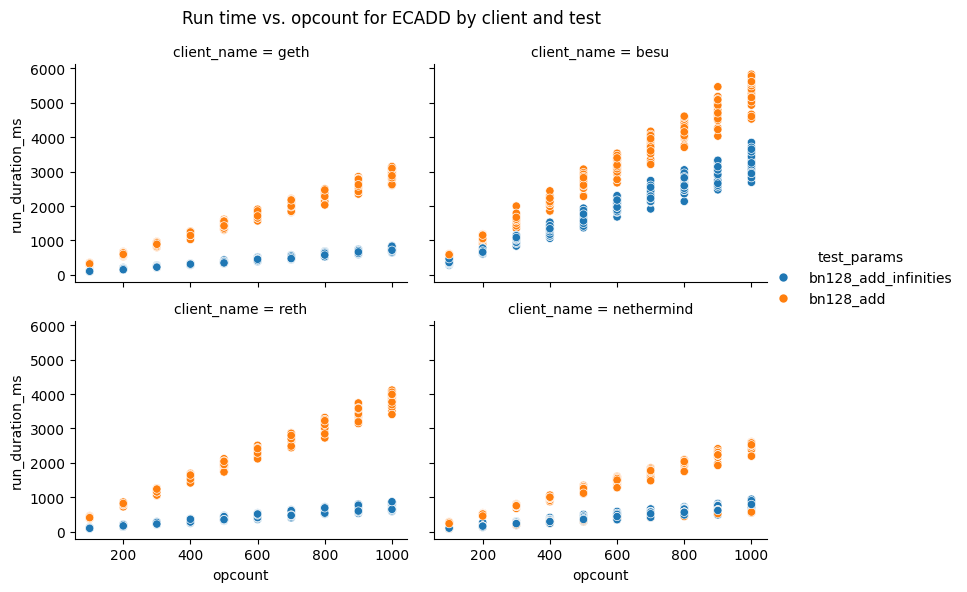

In [19]:
op_df = gas_bench_df[gas_bench_df["test_opcode"] == "ECADD"]
g = sns.relplot(
    data=op_df,
    x="opcount",
    y="run_duration_ms",
    hue="test_params",
    col="client_name",
    kind="scatter",
    height=3,
    aspect=1,
    col_wrap=2,
)
plt.suptitle("Run time vs. opcount for ECADD by client and test")
sns.move_legend(g, "upper left", bbox_to_anchor=(0.96, 0.6))
plt.tight_layout()
plt.show()

## ecPairing

The opcode count in ecPairing seems to be broken. We need to fix it

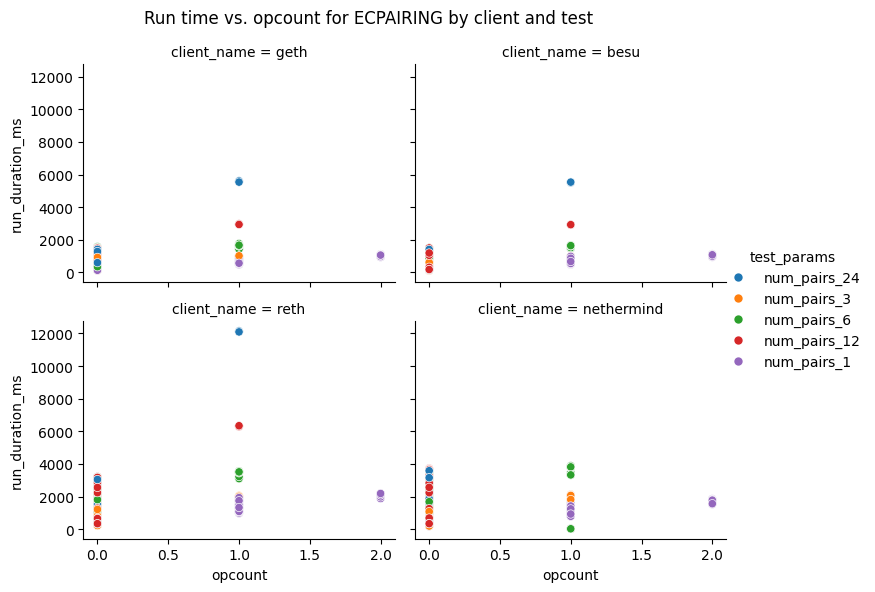

In [20]:
op_df = gas_bench_df[gas_bench_df["test_opcode"] == "ECPAIRING"]
g = sns.relplot(
    data=op_df,
    x="opcount",
    y="run_duration_ms",
    hue="test_params",
    col="client_name",
    kind="scatter",
    height=3,
    aspect=1,
    col_wrap=2,
)
plt.suptitle("Run time vs. opcount for ECPAIRING by client and test")
sns.move_legend(g, "upper left", bbox_to_anchor=(0.96, 0.6))
plt.tight_layout()
plt.show()